In [62]:
import pandas as pd
import numpy as np

content_df = pd.read_csv(
    r"D:\content_data.csv"
)

print("Dataset loaded successfully!")
print("Shape:", content_df.shape)

content_df.head()

Dataset loaded successfully!
Shape: (500, 13)


,content_id,topic,content_type,length_sec,hook_type,posting_time,likes,shares,saves,comments,retention_rate,caption_style,followers_gained
0,C0001,Dating,Short Video,38,Visual,12:00,1657,264,301,41,69.84,Story,218
1,C0002,Dating,Short Video,33,Visual,09:00,1168,210,212,71,65.64,Question,397
2,C0003,Friendship,Long Video,137,Visual,20:00,889,68,98,30,65.99,Story,104
3,C0004,Loneliness,Long Video,135,Text,09:00,1699,159,312,40,56.69,Story,239
4,C0005,Loneliness,Image,0,Visual,17:00,2823,225,472,151,51.86,Question,507


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# Check content dataset

print("Shape:", content_df.shape)

print("\nColumn names:")
print(content_df.columns.tolist())

print("\nMissing values:")
print(content_df.isnull().sum())

print("\nDuplicate rows:", content_df.duplicated().sum())

Shape: (500, 13)

Column names:
['content_id', 'topic', 'content_type', 'length_sec', 'hook_type', 'posting_time', 'likes', 'shares', 'saves', 'comments', 'retention_rate', 'caption_style', 'followers_gained']

Missing values:
content_id          0
topic               0
content_type        0
length_sec          0
hook_type           0
posting_time        0
likes               0
shares              0
saves               0
comments            0
retention_rate      0
caption_style       0
followers_gained    0
dtype: int64

Duplicate rows: 0


In [65]:
print("Shape:", content_df.shape)

print("\nColumns:")
print(content_df.columns.tolist())

print("\nData types:")
print(content_df.dtypes)

print("\nMissing values:")
print(content_df.isnull().sum())

print("\nDuplicate rows:")
print(content_df.duplicated().sum())

Shape: (500, 13)

Columns:
['content_id', 'topic', 'content_type', 'length_sec', 'hook_type', 'posting_time', 'likes', 'shares', 'saves', 'comments', 'retention_rate', 'caption_style', 'followers_gained']

Data types:
content_id              str
topic                   str
content_type            str
length_sec            int64
hook_type               str
posting_time            str
likes                 int64
shares                int64
saves                 int64
comments              int64
retention_rate      float64
caption_style           str
followers_gained      int64
dtype: object

Missing values:
content_id          0
topic               0
content_type        0
length_sec          0
hook_type           0
posting_time        0
likes               0
shares              0
saves               0
comments            0
retention_rate      0
caption_style       0
followers_gained    0
dtype: int64

Duplicate rows:
0


In [66]:
content_df.columns = (
    content_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(content_df.columns.tolist())

['content_id', 'topic', 'content_type', 'length_sec', 'hook_type', 'posting_time', 'likes', 'shares', 'saves', 'comments', 'retention_rate', 'caption_style', 'followers_gained']


In [67]:
for col in content_df.columns:
    if content_df[col].dtype == "object":
        content_df[col] = content_df[col].astype(str).str.replace("*", "", regex=False)

print("Special characters cleaned.")

Special characters cleaned.


In [68]:
numeric_columns = [
    "length_sec",
    "likes",
    "shares",
    "saves",
    "comments",
    "retention_rate",
    "followers_gained"
]

for col in numeric_columns:
    content_df[col] = pd.to_numeric(
        content_df[col],
        errors="coerce"
    )

print(content_df[numeric_columns].dtypes)

length_sec            int64
likes                 int64
shares                int64
saves                 int64
comments              int64
retention_rate      float64
followers_gained      int64
dtype: object


In [69]:
text_columns = [
    "content_id",
    "topic",
    "content_type",
    "hook_type",
    "posting_time",
    "caption_style"
]

for col in text_columns:
    content_df[col] = content_df[col].astype(str).str.strip()

print("Text columns cleaned.")

Text columns cleaned.


In [70]:
print(content_df.isnull().sum())

content_id          0
topic               0
content_type        0
length_sec          0
hook_type           0
posting_time        0
likes               0
shares              0
saves               0
comments            0
retention_rate      0
caption_style       0
followers_gained    0
dtype: int64


In [71]:
print("Duplicate content IDs:",
      content_df["content_id"].duplicated().sum())

content_df = content_df.drop_duplicates(
    subset=["content_id"],
    keep="first"
)

print("Shape after duplicate removal:", content_df.shape)

Duplicate content IDs: 0
Shape after duplicate removal: (500, 13)


In [72]:
print("First ID:", content_df["content_id"].min())
print("Last ID:", content_df["content_id"].max())
print("Number of unique IDs:", content_df["content_id"].nunique())

First ID: C0001
Last ID: C0500
Number of unique IDs: 500


In [73]:
content_df["total_engagement"] = (
    content_df["likes"]
    + content_df["shares"]
    + content_df["saves"]
    + content_df["comments"]
)

content_df["engagement_rate"] = (
    content_df["total_engagement"]
    / content_df["followers_gained"].replace(0, np.nan)
)

content_df["share_rate"] = (
    content_df["shares"]
    / content_df["total_engagement"].replace(0, np.nan)
)

content_df["save_rate"] = (
    content_df["saves"]
    / content_df["total_engagement"].replace(0, np.nan)
)

content_df["comment_rate"] = (
    content_df["comments"]
    / content_df["total_engagement"].replace(0, np.nan)
)

content_df.head()

,content_id,topic,content_type,length_sec,hook_type,posting_time,likes,shares,saves,comments,retention_rate,caption_style,followers_gained,total_engagement,engagement_rate,share_rate,save_rate,comment_rate
0,C0001,Dating,Short Video,38,Visual,12:00,1657,264,301,41,69.84,Story,218,2263,10.380734,0.116659,0.133009,0.018118
1,C0002,Dating,Short Video,33,Visual,09:00,1168,210,212,71,65.64,Question,397,1661,4.183879,0.126430,0.127634,0.042745
2,C0003,Friendship,Long Video,137,Visual,20:00,889,68,98,30,65.99,Story,104,1085,10.432692,0.062673,0.090323,0.027650
3,C0004,Loneliness,Long Video,135,Text,09:00,1699,159,312,40,56.69,Story,239,2210,9.246862,0.071946,0.141176,0.018100
4,C0005,Loneliness,Image,0,Visual,17:00,2823,225,472,151,51.86,Question,507,3671,7.240631,0.061291,0.128575,0.041133


In [74]:
print("===== CONTENT OVERVIEW =====")

print("Total content:", len(content_df))
print("Total likes:", content_df["likes"].sum())
print("Total shares:", content_df["shares"].sum())
print("Total saves:", content_df["saves"].sum())
print("Total comments:", content_df["comments"].sum())

print(
    "Average retention rate:",
    round(content_df["retention_rate"].mean(), 2)
)

print(
    "Average engagement:",
    round(content_df["total_engagement"].mean(), 2)
)

===== CONTENT OVERVIEW =====
Total content: 500
Total likes: 731078
Total shares: 89563
Total saves: 120908
Total comments: 33745
Average retention rate: 71.02
Average engagement: 1950.59


In [75]:
topic_analysis = (
    content_df
    .groupby("topic")
    .agg(
        content_count=("content_id", "count"),
        total_likes=("likes", "sum"),
        total_shares=("shares", "sum"),
        total_saves=("saves", "sum"),
        total_comments=("comments", "sum"),
        avg_retention=("retention_rate", "mean"),
        avg_engagement=("total_engagement", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

topic_analysis

,content_count,total_likes,total_shares,total_saves,total_comments,avg_retention,avg_engagement
topic,,,,,,,
Self Confidence,53,81247,9242,13467,3967,70.902264,2036.283019
Social Anxiety,51,77515,9325,12780,3833,70.074902,2028.490196
Dating,77,116612,14391,19120,5310,70.891558,2018.610390
Overthinking,55,83410,9822,13481,4018,72.426182,2013.290909
Relationships,73,109079,13585,18905,4911,70.766164,2006.575342
Loneliness,63,94328,11546,15705,3932,71.969048,1992.238095
Friendship,57,75297,9785,12257,3488,68.825263,1768.894737
Work Stress,71,93590,11867,15193,4286,72.002676,1759.661972


In [76]:
content_type_analysis = (
    content_df
    .groupby("content_type")
    .agg(
        content_count=("content_id", "count"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_saves=("saves", "mean"),
        avg_comments=("comments", "mean"),
        avg_retention=("retention_rate", "mean"),
        avg_engagement=("total_engagement", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

content_type_analysis

,content_count,avg_likes,avg_shares,avg_saves,avg_comments,avg_retention,avg_engagement
content_type,,,,,,,
Carousel,115,1568.382609,188.504348,252.513043,74.660870,72.036087,2084.060870
Image,116,1495.982759,182.310345,255.448276,67.250000,68.994828,2000.991379
Long Video,139,1415.280576,171.920863,232.467626,64.913669,63.435324,1884.582734
Short Video,130,1388.123077,175.692308,230.184615,64.115385,80.029846,1858.115385


In [77]:
hook_analysis = (
    content_df
    .groupby("hook_type")
    .agg(
        content_count=("content_id", "count"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_saves=("saves", "mean"),
        avg_comments=("comments", "mean"),
        avg_retention=("retention_rate", "mean"),
        avg_engagement=("total_engagement", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

hook_analysis

,content_count,avg_likes,avg_shares,avg_saves,avg_comments,avg_retention,avg_engagement
hook_type,,,,,,,
Text,274,1484.390511,178.791971,242.291971,66.675182,70.990912,1972.149635
Visual,226,1435.199115,179.530973,241.238938,68.477876,71.050575,1924.446903


In [78]:
caption_analysis = (
    content_df
    .groupby("caption_style")
    .agg(
        content_count=("content_id", "count"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_saves=("saves", "mean"),
        avg_comments=("comments", "mean"),
        avg_retention=("retention_rate", "mean"),
        avg_engagement=("total_engagement", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

caption_analysis

,content_count,avg_likes,avg_shares,avg_saves,avg_comments,avg_retention,avg_engagement
caption_style,,,,,,,
Advice,125,1559.200000,188.320000,263.344000,75.992000,71.501760,2086.856000
Question,121,1455.198347,181.793388,231.570248,63.446281,71.678017,1932.008264
Statement,146,1433.904110,178.684932,232.849315,65.184932,71.321986,1910.623288
Story,108,1395.824074,166.092593,240.500000,65.296296,69.307130,1867.712963


In [79]:
content_df["posting_hour"] = (
    content_df["posting_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

time_analysis = (
    content_df
    .groupby("posting_hour")
    .agg(
        content_count=("content_id", "count"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_saves=("saves", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("total_engagement", "mean"),
        avg_retention=("retention_rate", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

time_analysis

,content_count,avg_likes,avg_shares,avg_saves,avg_comments,avg_engagement,avg_retention
posting_hour,,,,,,,
12,83,1495.626506,191.903614,244.759036,68.409639,2000.698795,70.710843
17,81,1491.160494,183.370370,250.950617,71.358025,1996.839506,69.269506
19,91,1472.659341,170.263736,257.417582,70.076923,1970.417582,71.822308
21,82,1473.707317,192.902439,231.585366,67.341463,1965.536585,72.231341
9,81,1425.370370,165.802469,235.740741,66.629630,1893.543210,70.939136
20,82,1412.756098,171.219512,228.731707,60.865854,1873.573171,71.027317


In [80]:
# Create performance score

content_df["performance_score"] = (
    content_df["likes"] * 0.30
    + content_df["shares"] * 0.25
    + content_df["saves"] * 0.25
    + content_df["comments"] * 0.20
)

content_df["performance_rank"] = (
    content_df["performance_score"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

print("Performance score created successfully!")

content_df[
    ["content_id", "total_engagement", "performance_score", "performance_rank"]
].head()

Performance score created successfully!


,content_id,total_engagement,performance_score,performance_rank
0,C0001,2263,646.55,151
1,C0002,1661,470.10,273
2,C0003,1085,314.20,406
3,C0004,2210,635.45,159
4,C0005,3671,1051.35,34


In [81]:
top_10_content = (
    content_df
    .sort_values("performance_score", ascending=False)
    .head(10)
)

top_10_content[
    [
        "content_id",
        "topic",
        "content_type",
        "likes",
        "shares",
        "saves",
        "comments",
        "retention_rate",
        "total_engagement",
        "performance_score"
    ]
]

,content_id,topic,content_type,likes,shares,saves,comments,retention_rate,total_engagement,performance_score
360,C0361,Overthinking,Image,4343,836,790,275,70.25,6244,1764.40
284,C0285,Dating,Short Video,4131,615,959,232,84.03,5937,1679.20
241,C0242,Dating,Image,4825,254,546,74,75.90,5699,1662.30
499,C0500,Friendship,Image,4225,499,790,131,78.22,5645,1615.95
253,C0254,Relationships,Long Video,4068,286,806,167,62.13,5327,1526.80
27,C0028,Friendship,Short Video,3841,532,749,61,80.87,5183,1484.75
78,C0079,Relationships,Carousel,4022,368,450,181,64.13,5021,1447.30
147,C0148,Dating,Carousel,3206,394,744,214,67.01,4558,1289.10
313,C0314,Relationships,Long Video,3344,359,592,177,52.38,4472,1276.35
302,C0303,Social Anxiety,Carousel,3434,488,384,130,81.35,4436,1274.20


In [82]:
bottom_10_content = (
    content_df
    .sort_values("performance_score", ascending=True)
    .head(10)
)

bottom_10_content[
    [
        "content_id",
        "topic",
        "content_type",
        "likes",
        "shares",
        "saves",
        "comments",
        "retention_rate",
        "total_engagement",
        "performance_score"
    ]
]

,content_id,topic,content_type,likes,shares,saves,comments,retention_rate,total_engagement,performance_score
410,C0411,Dating,Long Video,239,32,44,4,72.30,319,91.50
221,C0222,Relationships,Long Video,251,22,48,9,75.94,330,94.60
138,C0139,Relationships,Short Video,280,30,49,7,70.64,366,105.15
195,C0196,Friendship,Short Video,343,52,65,11,94.48,471,134.35
440,C0441,Overthinking,Short Video,389,22,42,17,71.48,470,136.10
320,C0321,Social Anxiety,Short Video,361,36,84,5,85.58,486,139.30
474,C0475,Self Confidence,Long Video,369,25,83,9,57.39,486,139.50
92,C0093,Relationships,Short Video,386,55,46,7,69.00,494,142.45
50,C0051,Friendship,Image,378,63,47,16,53.14,504,144.10
146,C0147,Relationships,Short Video,383,36,92,24,69.34,535,151.70


In [83]:
best_topic = topic_analysis.index[0]

print("Best performing topic:", best_topic)

Best performing topic: Self Confidence


In [84]:
best_content_type = content_type_analysis.index[0]

print("Best performing content type:", best_content_type)

Best performing content type: Carousel


In [85]:
best_hook = hook_analysis.index[0]

print("Best performing hook:", best_hook)

Best performing hook: Text


In [86]:
best_caption = caption_analysis.index[0]

print("Best performing caption style:", best_caption)

Best performing caption style: Advice


In [87]:
best_posting_hour = time_analysis.index[0]

print("Best posting hour:", best_posting_hour)

Best posting hour: 12


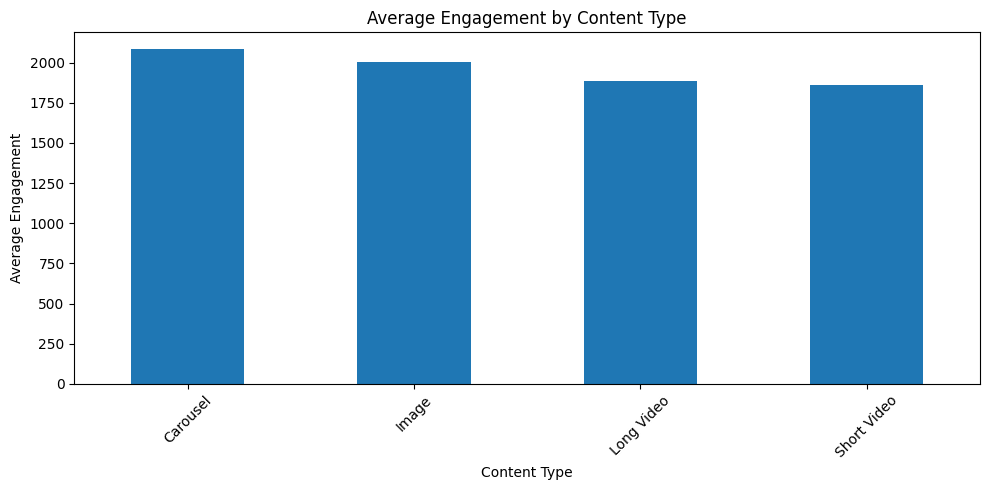

In [88]:
content_type_analysis["avg_engagement"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Engagement by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

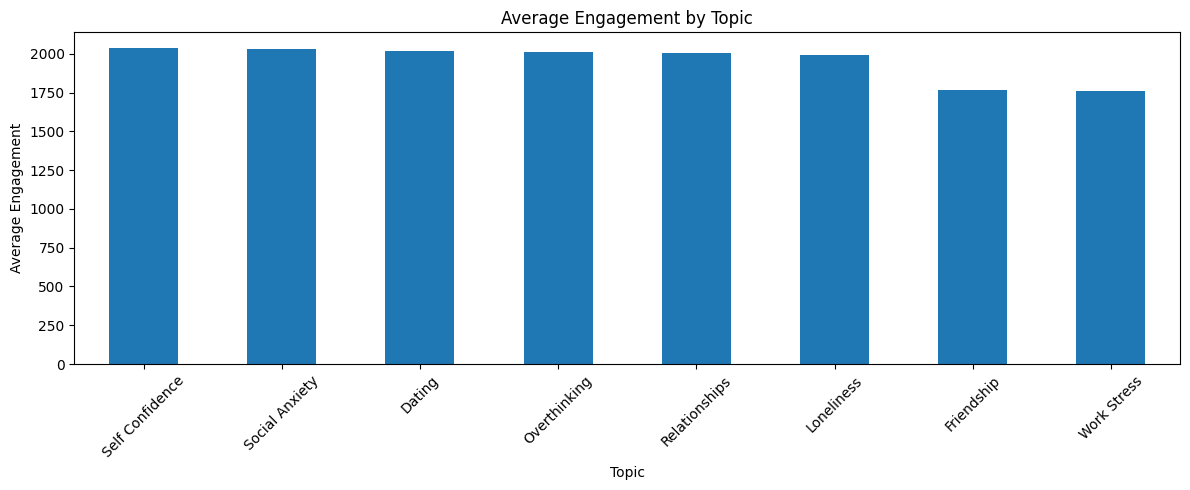

In [89]:
topic_analysis["avg_engagement"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Engagement by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

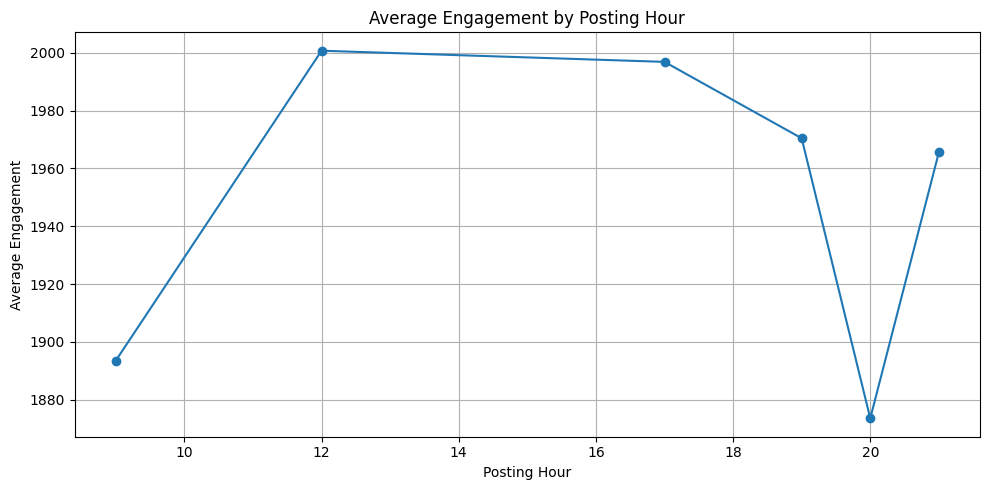

In [90]:
time_analysis.sort_index()["avg_engagement"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Engagement by Posting Hour")
plt.xlabel("Posting Hour")
plt.ylabel("Average Engagement")
plt.grid(True)
plt.tight_layout()
plt.show()

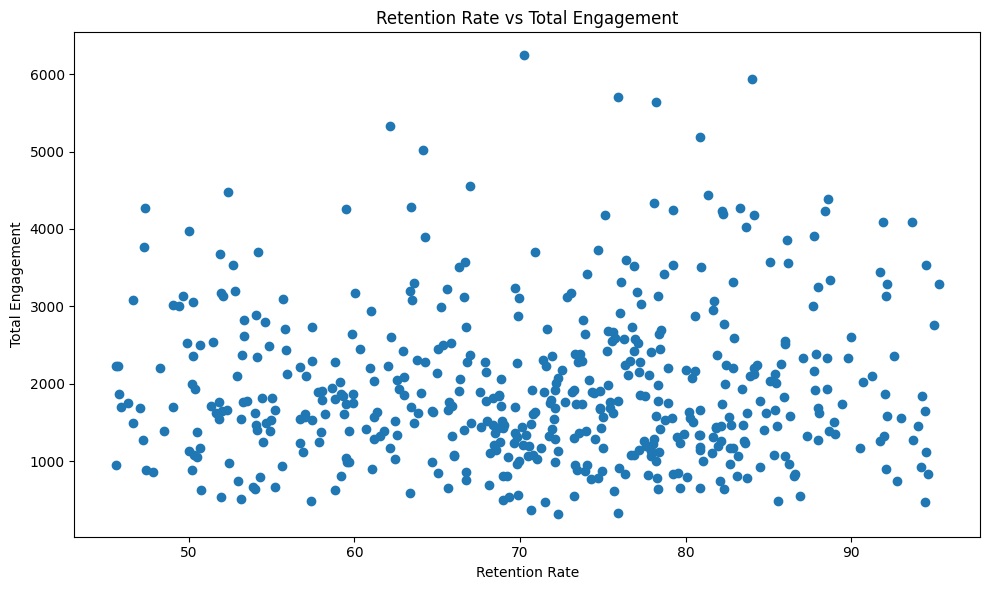

In [92]:
plt.figure(figsize=(10, 6))

plt.scatter(
    content_df["retention_rate"],
    content_df["total_engagement"]
)

plt.title("Retention Rate vs Total Engagement")
plt.xlabel("Retention Rate")
plt.ylabel("Total Engagement")
plt.tight_layout()
plt.show()

In [95]:
content_df.to_csv(
    r"D:\content_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [97]:
topic_analysis.to_csv(
    r"D:\content_cleaned.csv"
)

content_type_analysis.to_csv(
    r"D:\content_cleaned.csv"
)

hook_analysis.to_csv(
    r"D:\content_cleaned.csv"
)

caption_analysis.to_csv(
    r"D:\content_cleaned.csv"
)

time_analysis.to_csv(
    r"D:\content_cleaned.csv"
)

print("All analysis files saved successfully!")

All analysis files saved successfully!
